In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("C:/Users/keshv/OneDrive/Desktop/Data_Science/Jupyter_lab/Data Set/vehicles.csv")

In [4]:
df.shape

(426880, 26)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [6]:
len(df.select_dtypes(include = "object").columns)

19

In [7]:
len(df.select_dtypes(include = "number").columns)

7

In [8]:
df = df.drop(columns = ["id", "url", "region_url", "VIN", "image_url", "description", "county", "state", "lat", "long"])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        426880 non-null  object 
 1   price         426880 non-null  int64  
 2   year          425675 non-null  float64
 3   manufacturer  409234 non-null  object 
 4   model         421603 non-null  object 
 5   condition     252776 non-null  object 
 6   cylinders     249202 non-null  object 
 7   fuel          423867 non-null  object 
 8   odometer      422480 non-null  float64
 9   title_status  418638 non-null  object 
 10  transmission  424324 non-null  object 
 11  drive         296313 non-null  object 
 12  size          120519 non-null  object 
 13  type          334022 non-null  object 
 14  paint_color   296677 non-null  object 
 15  posting_date  426812 non-null  object 
dtypes: float64(2), int64(1), object(13)
memory usage: 52.1+ MB


In [10]:
df["cylinders"].unique()

array([nan, '8 cylinders', '6 cylinders', '4 cylinders', '5 cylinders',
       'other', '3 cylinders', '10 cylinders', '12 cylinders'],
      dtype=object)

In [11]:
df["title_status"].unique()

array([nan, 'clean', 'rebuilt', 'lien', 'salvage', 'missing',
       'parts only'], dtype=object)

In [12]:
df["transmission"].unique()

array([nan, 'other', 'automatic', 'manual'], dtype=object)

In [13]:
df["drive"].unique()

array([nan, 'rwd', '4wd', 'fwd'], dtype=object)

In [14]:
df["size"].unique()

array([nan, 'full-size', 'mid-size', 'compact', 'sub-compact'],
      dtype=object)

In [15]:
df["fuel"].unique()

array([nan, 'gas', 'other', 'diesel', 'hybrid', 'electric'], dtype=object)

In [16]:
df["condition"].unique()

array([nan, 'good', 'excellent', 'fair', 'like new', 'new', 'salvage'],
      dtype=object)

In [17]:
df["type"].unique()

array([nan, 'pickup', 'truck', 'other', 'coupe', 'SUV', 'hatchback',
       'mini-van', 'sedan', 'offroad', 'bus', 'van', 'convertible',
       'wagon'], dtype=object)

In [18]:
df["paint_color"].unique()

array([nan, 'white', 'blue', 'red', 'black', 'silver', 'grey', 'brown',
       'yellow', 'orange', 'green', 'custom', 'purple'], dtype=object)

In [19]:
df["posting_date"] = pd.to_datetime(
    df["posting_date"],
    utc=True,
    errors="coerce"
)
df["car_age"] = df["posting_date"].dt.year - df["year"]

In [20]:
df.isnull().sum().sort_values(ascending = False)

size            306361
cylinders       177678
condition       174104
drive           130567
paint_color     130203
type             92858
manufacturer     17646
title_status      8242
model             5277
odometer          4400
fuel              3013
transmission      2556
car_age           1205
year              1205
posting_date        68
price                0
region               0
dtype: int64

In [21]:
df[["condition", "paint_color"]] = df[["condition", "paint_color"]].fillna("unknown")
df = df.drop(columns = "size")

In [22]:
df.drop(index = df[df["model"].isnull()].index, inplace = True)
df.drop(index = df[df["manufacturer"].isnull()].index, inplace = True)
df.drop(index = df[df["year"].isnull()].index, inplace = True)

In [23]:
df["odometer"] = df["odometer"].fillna(df["odometer"].median())
df["type"] = df["type"].fillna("unknown")

In [24]:
df.drop(columns = "cylinders", inplace = True)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 404020 entries, 27 to 426879
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype              
---  ------        --------------   -----              
 0   region        404020 non-null  object             
 1   price         404020 non-null  int64              
 2   year          404020 non-null  float64            
 3   manufacturer  404020 non-null  object             
 4   model         404020 non-null  object             
 5   condition     404020 non-null  object             
 6   fuel          401467 non-null  object             
 7   odometer      404020 non-null  float64            
 8   title_status  396302 non-null  object             
 9   transmission  401749 non-null  object             
 10  drive         283100 non-null  object             
 11  type          404020 non-null  object             
 12  paint_color   404020 non-null  object             
 13  posting_date  404020 non-null  datetime64[ns, UT

In [26]:
df = df.drop_duplicates()

In [27]:
df.isnull().sum().sort_values(ascending = False)

drive           120914
title_status      7708
fuel              2553
transmission      2271
region               0
price                0
year                 0
manufacturer         0
model                0
condition            0
odometer             0
type                 0
paint_color          0
posting_date         0
car_age              0
dtype: int64

In [28]:
df["drive"].unique()

array([nan, 'rwd', '4wd', 'fwd'], dtype=object)

In [29]:
df['drive'].value_counts(dropna = False)

drive
4wd    128308
NaN    120914
fwd    101218
rwd     53552
Name: count, dtype: int64

In [30]:
drive = df.groupby("manufacturer")["drive"].transform(lambda x : x.mode()[0])

In [31]:
df["drive"] = df["drive"].fillna(drive)

In [32]:
df["title_status"] = df["title_status"].fillna("unknown")

In [33]:
df["fuel"].unique()

array(['gas', 'other', 'diesel', 'hybrid', nan, 'electric'], dtype=object)

In [34]:
fuel = df.groupby("manufacturer")["fuel"].transform(lambda x : x.mode()[0])

In [35]:
df["fuel"] = df["fuel"].fillna(fuel)

In [36]:
transmission = df.groupby("manufacturer")["transmission"].transform(lambda x : x.mode()[0])

In [37]:
df["transmission"] = df["transmission"].fillna(transmission)

In [38]:
print(df["model"].nunique())
print(df["manufacturer"].nunique())
print(df["region"].nunique())
print(df["type"].nunique())
print(df["condition"].nunique())
print(df["paint_color"].nunique())

23753
41
404
14
7
13


In [39]:
df.drop(columns = ["model", "region", "posting_date"], inplace = True)

In [40]:
print(df["price"].describe())
print((df["price"] == 0).sum())
print((df["price"] < 0).sum())
print(df["price"].max())

count    4.039920e+05
mean     6.218861e+04
std      1.124293e+07
min      0.000000e+00
25%      5.995000e+03
50%      1.399500e+04
75%      2.642400e+04
max      3.736929e+09
Name: price, dtype: float64
30862
0
3736928711


In [41]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
lower = max(0, lower)
upper = Q3 + 1.5 * IQR

df = df[(df["price"] > lower) & (df["price"] <= upper)]

In [42]:
df.shape

(366116, 12)

In [43]:
df["price"].describe()

count    366116.000000
mean      17819.989085
std       12679.837598
min           1.000000
25%        7000.000000
50%       14995.000000
75%       26983.250000
max       57029.000000
Name: price, dtype: float64

In [44]:
df.to_csv("cleaned_data.csv", index=False)

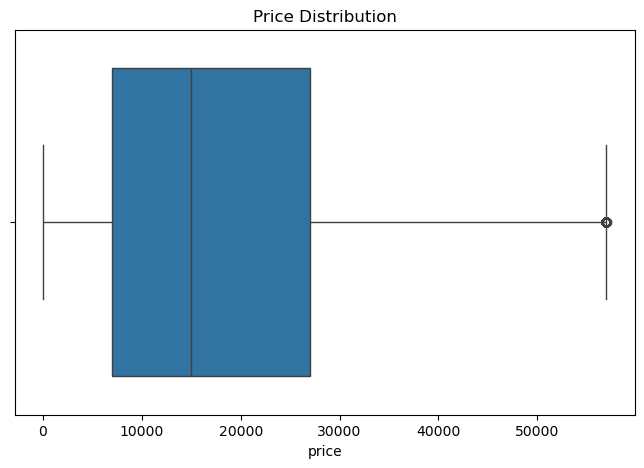

In [45]:
plt.figure(figsize = (8, 5))
sns.boxplot(x = df["price"])
plt.title("Price Distribution")
plt.show()

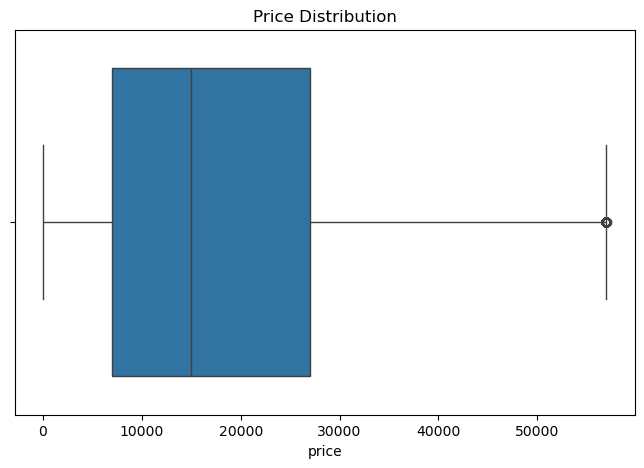

In [46]:
plt.figure(figsize = (8, 5))
sns.boxplot(x = df["price"])
plt.title("Price Distribution")
plt.show()

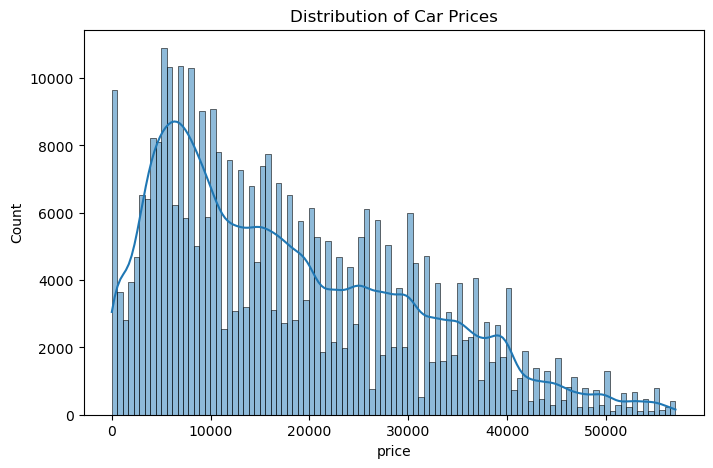

In [47]:
plt.figure(figsize = (8, 5))
sns.histplot(df["price"], kde = True)
plt.title("Distribution of Car Prices")
plt.show()

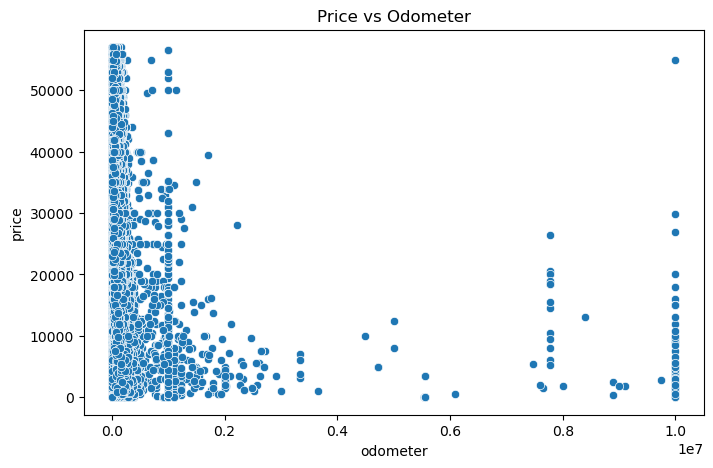

In [48]:
plt.figure(figsize = (8, 5))
sns.scatterplot(x = "odometer", y = "price", data = df)
plt.title("Price vs Odometer")
plt.show()